# Coupled Molecular Motors

In cells, active forces and vesicular transport are provided by molecular walkers, which walk along filaments in a preferred direction. Their motion is a result of the coupling of various individual molecular motors $j$. A molecular walker carrying a vesicle is shown in the video available: [link](https://www.youtube.com/watch?v=y-uuk4Pr2i8). The coupled molecular motors are modelled using a system switching between two potentials, one being flat and the other ratchet. The motion is then affected by the thermal noise and stochastic switching between the two potential states. As each motor is coupled, the force of each motor approximately contributes to the total force on the filamentous backbone. Refer to Section 3.1.6 of [arXiv:1202.2442](https://arxiv.org/abs/1202.2442) for a detailed discussion.

The equations for the overdamped dynamics of the backbone read:

$$
\lambda \dot{x} =
F_{\mathrm{ext}} - \frac{1}{N}
\sum_{j=1}^{N}
\sigma_j \,
W'\!\big(x + j \cdot q\big) + \sqrt{\frac{k_B T \lambda}{N}}\, \eta(t)
\qquad \tag{1}
$$

$$
\sigma_j = 0
\xrightleftharpoons[r_1(x + j \cdot q)]{r_0}
\sigma_j = 1
$$

where:

- $x(t)$ is the backbone position  
- $\lambda$ is the friction coefficient  
- $F_{\mathrm{ext}}$ is the external force  
- $N$ is the number of coupled units  
- $\sigma_j(t)$ is the internal state variable ($\sigma_j \in \{0,1\}$). It represents a two-state switching degree of freedom (ATP attached/unattached)
- $W'(x)$ is the derivative of the interaction potential $W(x)$  
- $q$ is the spatial coupling offset between units  
- $k_B T$ sets the noise strength (thermal energy scale)
- $r_0$ is the transition rate $0 \rightarrow 1$
- $r_1$ is the transition rate $1 \rightarrow 0$
  
$$ r_1 =
\begin{cases}
\hat{r_1} &  \text{if d away from the potential minimum} \\
0 &    \text{otherwise}
\end{cases}
$$
- $\eta(t)$ is Gaussian white noise with  
  $$
  \langle \eta(t) \rangle = 0, 
  \qquad
  \langle \eta(t)\eta(t') \rangle = \delta(t - t')
  $$

#### The dynamics of the model are as follows:

1. Initialize parameters: number of motors $N$, timestep $\Delta t$, total steps, system size $L$, motor spacing $q$, detachment width $d$, friction $\gamma$, temperature $T$, and external force $F_{\mathrm{ext}}$. Set initial backbone position $x(0)$ and random motor states $\sigma_j \in \{0,1\}$.

2. For each time step, compute motor positions relative to the backbone:
   $$
   x_j = x + j \cdot q
   $$

3. Apply periodic mapping:
   $$
   y_j = x_j \bmod L
   $$
   and identify motors in the active region near potential boundaries.

4. Compute position-dependent detachment rates:
   motors close to potential minima (within distance $d/2$) have enhanced detachment:
   $$
   r_1(j) =
   \begin{cases}
   \hat r_1, & \text{if } y_j < d/2 \ \text{or}\ y_j > L - d/2 \\
   0, & \text{otherwise}
   \end{cases}
   $$

5. Define the two-state Markov process for each motor:
   $$
   0 \xrightleftharpoons[r_1(j)]{r_0} 1
   $$
   where:
   - $0 \to 1$: attachment with rate $r_0$  
   - $1 \to 0$: detachment with rate $r_1(j)$

   Convert rates to discrete-time transition probabilities:
   $$
   p_{\text{attach}} = 1 - e^{-r_0 \Delta t}, \quad
   p_{\text{detach}} = 1 - e^{-r_1(j)\Delta t}
   $$

   For each motor $j$:
   - draw $u_j \sim \mathcal{U}(0,1)$
   - if $\sigma_j = 0$ and $u_j < p_{\text{attach}}$, set $\sigma_j = 1$
   - if $\sigma_j = 1$ and $u_j < p_{\text{detach}}$, set $\sigma_j = 0$

6. Compute total motor force from active motors:
   $$
   F_{\text{motor}} = \frac{1}{N} \sum_j \sigma_j \, F_{\text{ratchet}}(x_j)
   $$

7. Generate thermal noise corresponding to temperature $T$.

8. Update backbone position using overdamped Langevin dynamics:
   $$
   x \leftarrow x + \frac{\Delta t}{\gamma}(F_{\mathrm{ext}} + F_{\mathrm{motor}}) + \text{noise}
   $$

9. Store backbone position and motor states; repeat for all time steps and compute attached fraction as post-processing.



In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from cmm_integrator import simulate_coupled_molecular_motors

In [2]:
n_steps = 100000
dt = 1e-3
results = simulate_coupled_molecular_motors(
    num_motors=50,
    dt=dt,
    n_steps=n_steps,
    L=1.0,
    a=0.25,
    U0=5.0,
    r0=1.0,
    r1_hat=15.0,
    T=0.5,
    fric=5.0,
    F_ext=0.0,
    seed=42
)


x = results["x"]
time = results["time"]
sigma_history = results["sigma_history"]
attached_fraction = results["attached_fraction"]

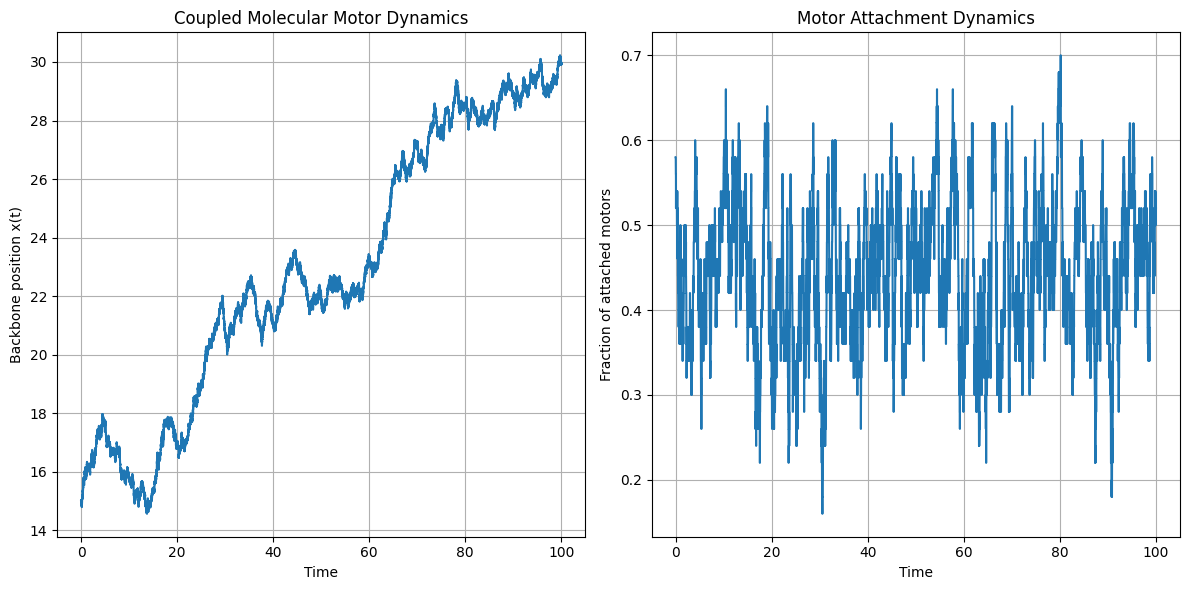

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# ------------------------------------------------------------
# Backbone position
# ------------------------------------------------------------
axes[0].plot(time, x)
axes[0].set_ylabel("Backbone position x(t)")
axes[0].set_xlabel("Time")
axes[0].set_title("Coupled Molecular Motor Dynamics")
axes[0].grid(True)

# ------------------------------------------------------------
# Attached fraction
# ------------------------------------------------------------
axes[1].plot(time, attached_fraction)
axes[1].set_xlabel("Time")
axes[1].set_ylabel("Fraction of attached motors")
axes[1].set_title("Motor Attachment Dynamics")
axes[1].grid(True)

plt.tight_layout()
plt.show()

## Coarse Graining



The above dynamics for $N \ge 1$ can be described by an Active Brownian Particle with speed-dependent noise. The dynamics is then given by
$$
\dot{x} = v,
$$

$$
\dot{v} = f(v) + g(v)\,\xi(t).
$$
Mean and variance of the instantaneous velocity changes should be proportional to $f(v)$ and $g(v)$, respectively. Using the data from the above simulation, we can extract the values of $f(v)$ and $g(v)$ and contract the particle trajectory using the corresponding Langevin equation. At the end, we can compare the coarse-grained results with the above simulation.  


#### Calculating $f(v)$ anf $g(v)$
We first compute the instantaneous velocity from the simulated position trajectory. It then measures how the velocity changes over a small coarse-grained time interval. These velocity changes are grouped by current velocity into bins.
For each velocity bin, the average change in velocity is computed to estimate the deterministic drift term, which describes the dynamics' systematic tendency. The variance of the velocity changes is also computed to estimate the diffusion term, which measures the strength of stochastic fluctuations or noise.
Finally, the square root of the diffusion is taken to obtain the noise amplitude as a function of velocity.

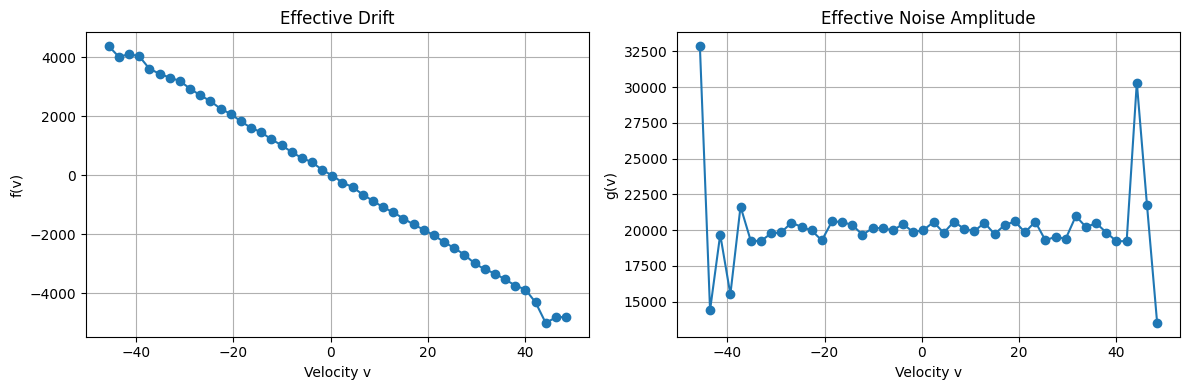

In [4]:
v = np.diff(x) / dt
# ============================================================
# ESTIMATE EFFECTIVE f(v) AND g(v)
# ============================================================
tau_steps = 10
tau = tau_steps * dt
dv = v[tau_steps:] - v[:-tau_steps]
v_mid = v[:-tau_steps]
n_bins = 60
bins = np.linspace(v_mid.min(), v_mid.max(), n_bins + 1)
bin_centers = 0.5 * (bins[:-1] + bins[1:])

drift = np.full(n_bins, np.nan)
diffusion = np.full(n_bins, np.nan)

for i in range(n_bins):
    mask = ((v_mid >= bins[i]) & (v_mid < bins[i + 1]))
    if np.sum(mask) > 20:
        drift[i] = np.mean(dv[mask]) / tau

        diffusion[i] = np.var(dv[mask]) / tau

# Remove NaNs
valid = (np.isfinite(drift) & np.isfinite(diffusion))

v_fit = bin_centers[valid]
f_fit = drift[valid]
g_fit = np.sqrt(diffusion[valid])
# ============================================================
# INTERPOLATE f(v) AND g(v)
# ============================================================
f_interp = interp1d(v_fit,f_fit,kind='linear', fill_value='extrapolate')
g_interp = interp1d(v_fit, g_fit, kind='linear', fill_value='extrapolate')
fig, axes = plt.subplots(1,2,figsize=(12, 4)) 

# ------------------------------------------------------------
# Drift function f(v)
# ------------------------------------------------------------

axes[0].plot(bin_centers, drift, 'o-')
axes[0].set_xlabel("Velocity v")
axes[0].set_ylabel("f(v)")
axes[0].set_title("Effective Drift")
axes[0].grid(True)

# ------------------------------------------------------------
# Noise amplitude g(v)
# ------------------------------------------------------------

axes[1].plot(bin_centers, diffusion, 'o-')
axes[1].set_xlabel("Velocity v")
axes[1].set_ylabel("g(v)")
axes[1].set_title("Effective Noise Amplitude")
axes[1].grid(True)
plt.tight_layout()
plt.show()

Now we simulate an effective coarse-grained Langevin model using the drift and noise functions previously extracted from the microscopic dynamics. It first initialises new position and velocity arrays for the effective model. At each timestep, the current velocity is used to evaluate the interpolated drift and noise amplitude functions. These are then used in an Euler–Maruyama update to evolve the effective velocity, accounting for both deterministic and stochastic contributions. The position is subsequently updated using the new velocity. Finally, the trajectory generated by this coarse-grained Langevin model is compared with the original microscopic simulation by plotting both position trajectories together.

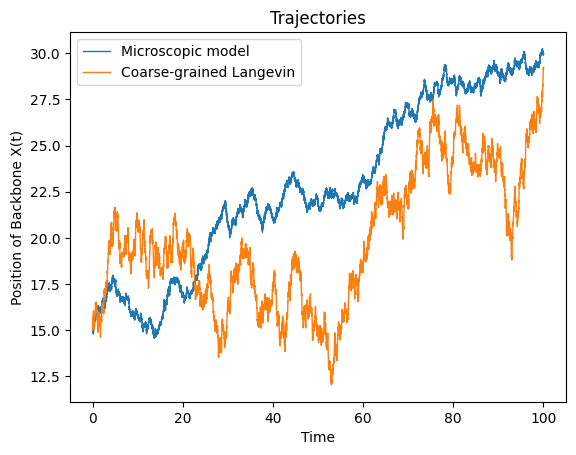

In [5]:
rng = np.random.default_rng(13)
v_eff = np.zeros(n_steps)
x_eff = np.zeros(n_steps)
x_eff[0] = x[0]
v_eff[0] = v[0]

for i in range(1, n_steps):
    current_v = v_eff[i-1]
    # Drift
    f = float(f_interp(current_v))
    # Noise amplitude
    g = np.abs(float(g_interp(current_v)))
    # Euler-Maruyama update
    v_eff[i] = (current_v+ f * dt+ g * np.sqrt(dt) * rng.normal())

    # Position update
    x_eff[i] = (x_eff[i-1]+ v_eff[i-1] * dt)

plt.plot(time,x, label='Microscopic model', linewidth=1)
plt.plot(time, x_eff, label='Coarse-grained Langevin', linewidth=1)
plt.xlabel("Time")
plt.ylabel("Position of Backbone X(t)")
plt.title("Trajectories")
plt.legend()
plt.show()

Although the individual trajectory realisations of the two systems differ due to their stochastic nature and the loss of microscopic details in the coarse-grained description, their long-time statistical behaviour remains approximately the same. In particular, the effective Langevin model reproduces the average transport properties of the original system reasonably well, indicating that the coarse-grained dynamics successfully capture the essential statistical features of the microscopic model, as shown below.

In [6]:
v_real_mean = (
    x[-1] - x[0]
) / (time[-1] - time[0])

v_eff_mean = (
    x_eff[-1] - x_eff[0]
) / (time[-1] - time[0])

print(f"Microscopic mean velocity     = {v_real_mean:.5f}")

print(f"Coarse-grained mean velocity  = {v_eff_mean:.5f}")

Microscopic mean velocity     = 0.14951
Coarse-grained mean velocity  = 0.14197
